# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40380629,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302960e+06,781.201636,0.304002,0.258254,4.526724,0.0,20.0,20.0000,-6.0224,0.027191,1.122812,0.000536,6.028159e+06,3.349485,2.651569,0.000088,0.000391
40380759,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302924e+06,953.465128,0.347109,0.295068,4.519408,0.0,20.0,20.0000,-1.9472,0.027191,1.122807,0.000652,6.028192e+06,3.349485,2.651569,0.000107,0.000477
40380889,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302337e+06,3407.396277,0.592525,0.476571,4.256211,0.0,20.0,20.0000,-8.3648,0.027186,1.122716,0.002318,6.028731e+06,3.349485,2.651569,0.000400,0.001704
40381019,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.288200e+06,55718.203782,1.532540,0.563869,1.900646,0.0,20.0,5.2784,-11.6576,0.027072,1.120509,0.213767,6.041715e+06,3.349485,2.651569,0.007469,0.027859


In [24]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag. ind.", "Harm ind.", "Tox. ind.", "Threshold"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

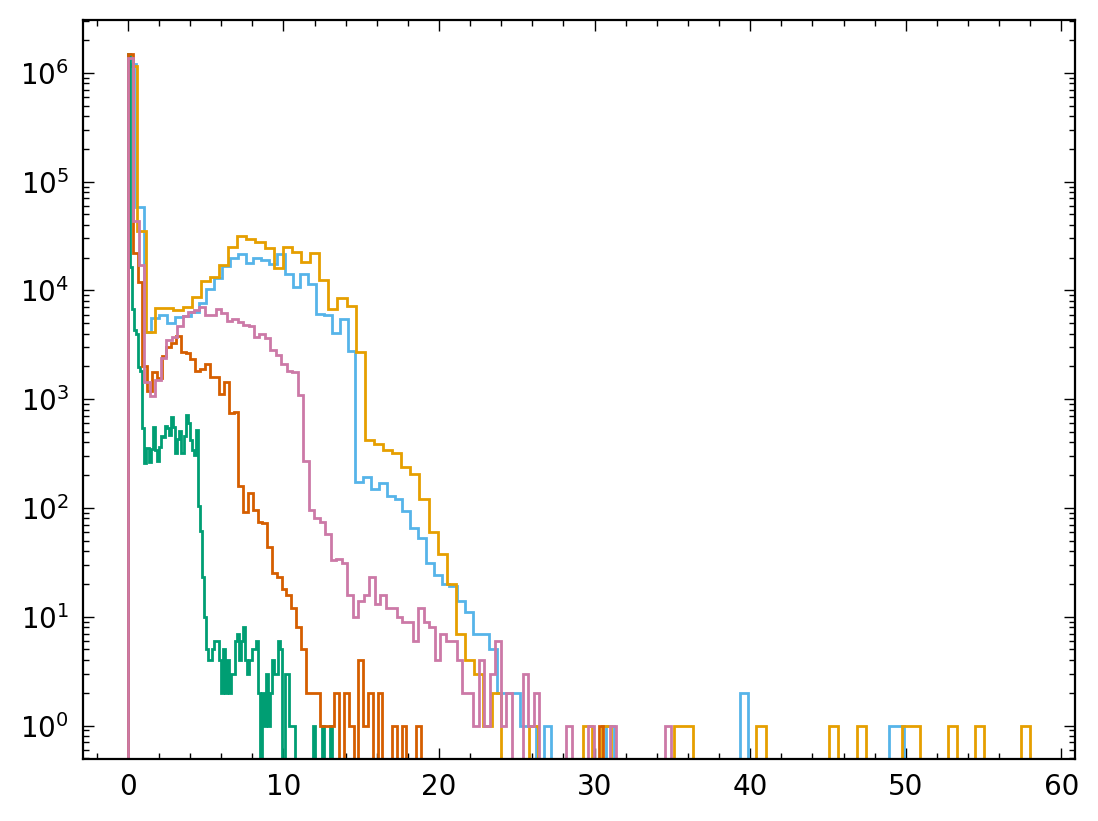

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-26.795884,1.677295,1.057779,0.659569
1,-6.698971,3.219364,1.061780,0.760424
2,0.700124,0.209304,1.158637,0.130757
3,0.717337,0.278717,1.340685,0.177058
4,0.735609,0.340858,1.457053,0.236215
...,...,...,...,...
100,2.677607,4.751940,1.657581,0.507273
101,2.813581,5.051276,1.657712,0.540712
102,3.349485,0.026946,1.117134,0.105809
103,5.359177,0.142602,1.113291,0.150815


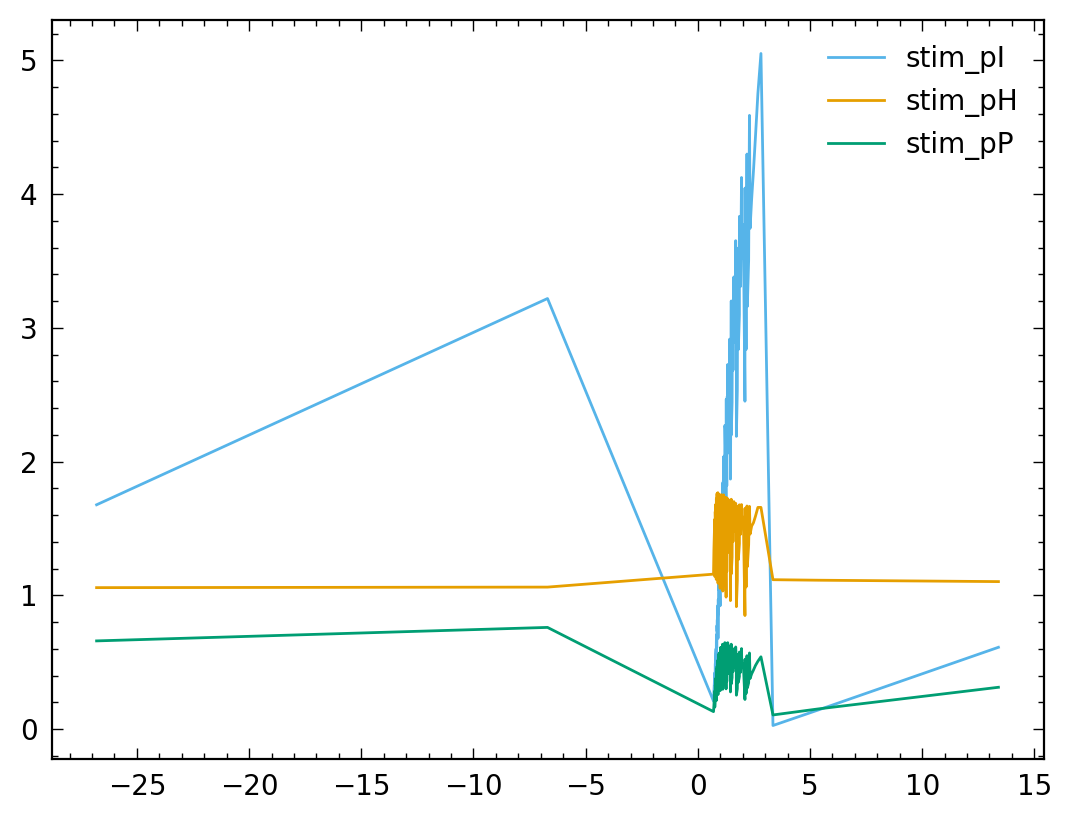

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 14
fevals: 12
fevals: 11
fevals: 12


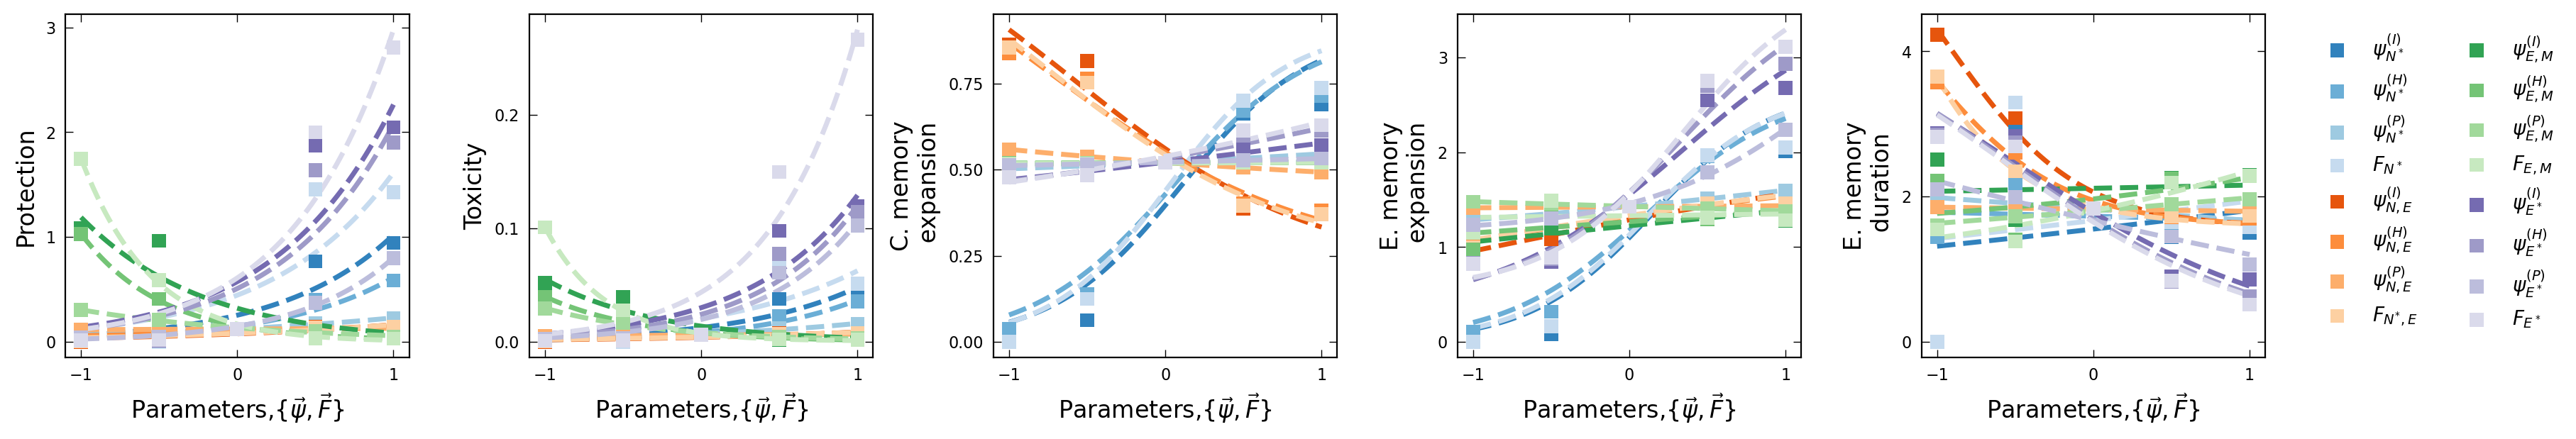

In [25]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*F0_max, -2*F0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*F0_max, 2*F0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='--',
                        linewidth = 2.5,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec F \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

In [16]:
# with pd.option_context('display.max_columns', None,'display.max_rows', None):
#     display(data_mean)

fevals: 9
fevals: 13
fevals: 14
fevals: 47


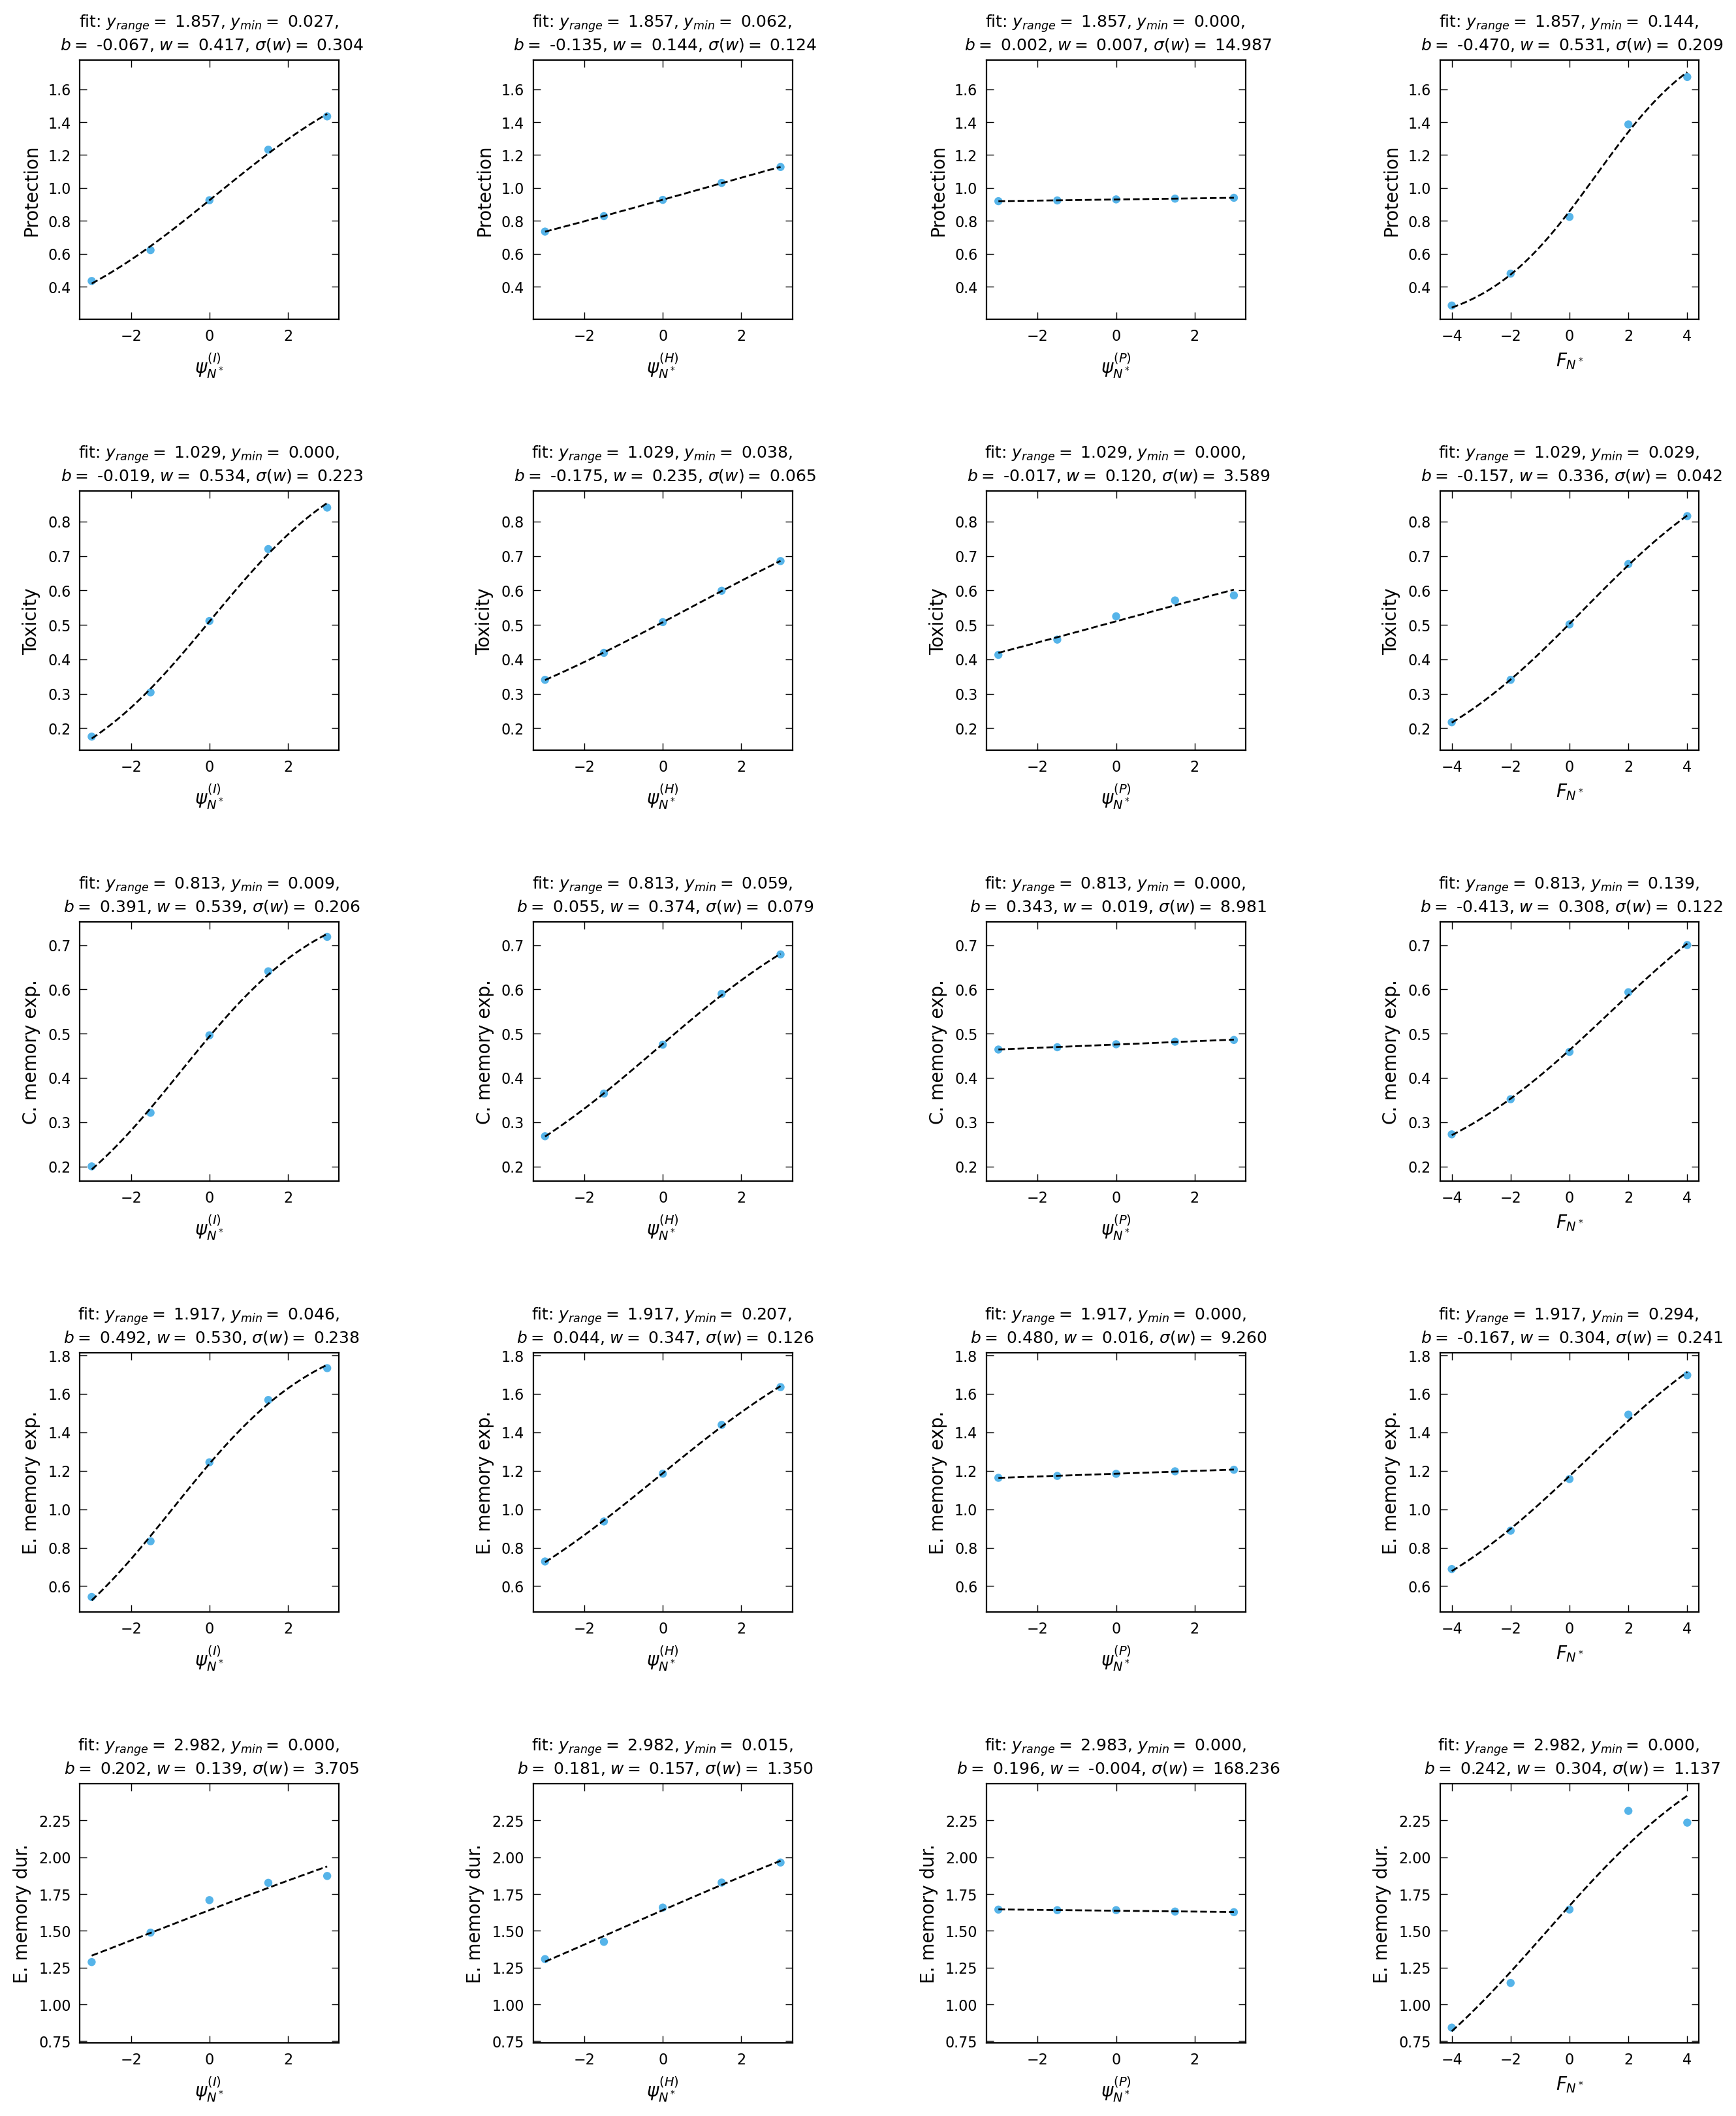

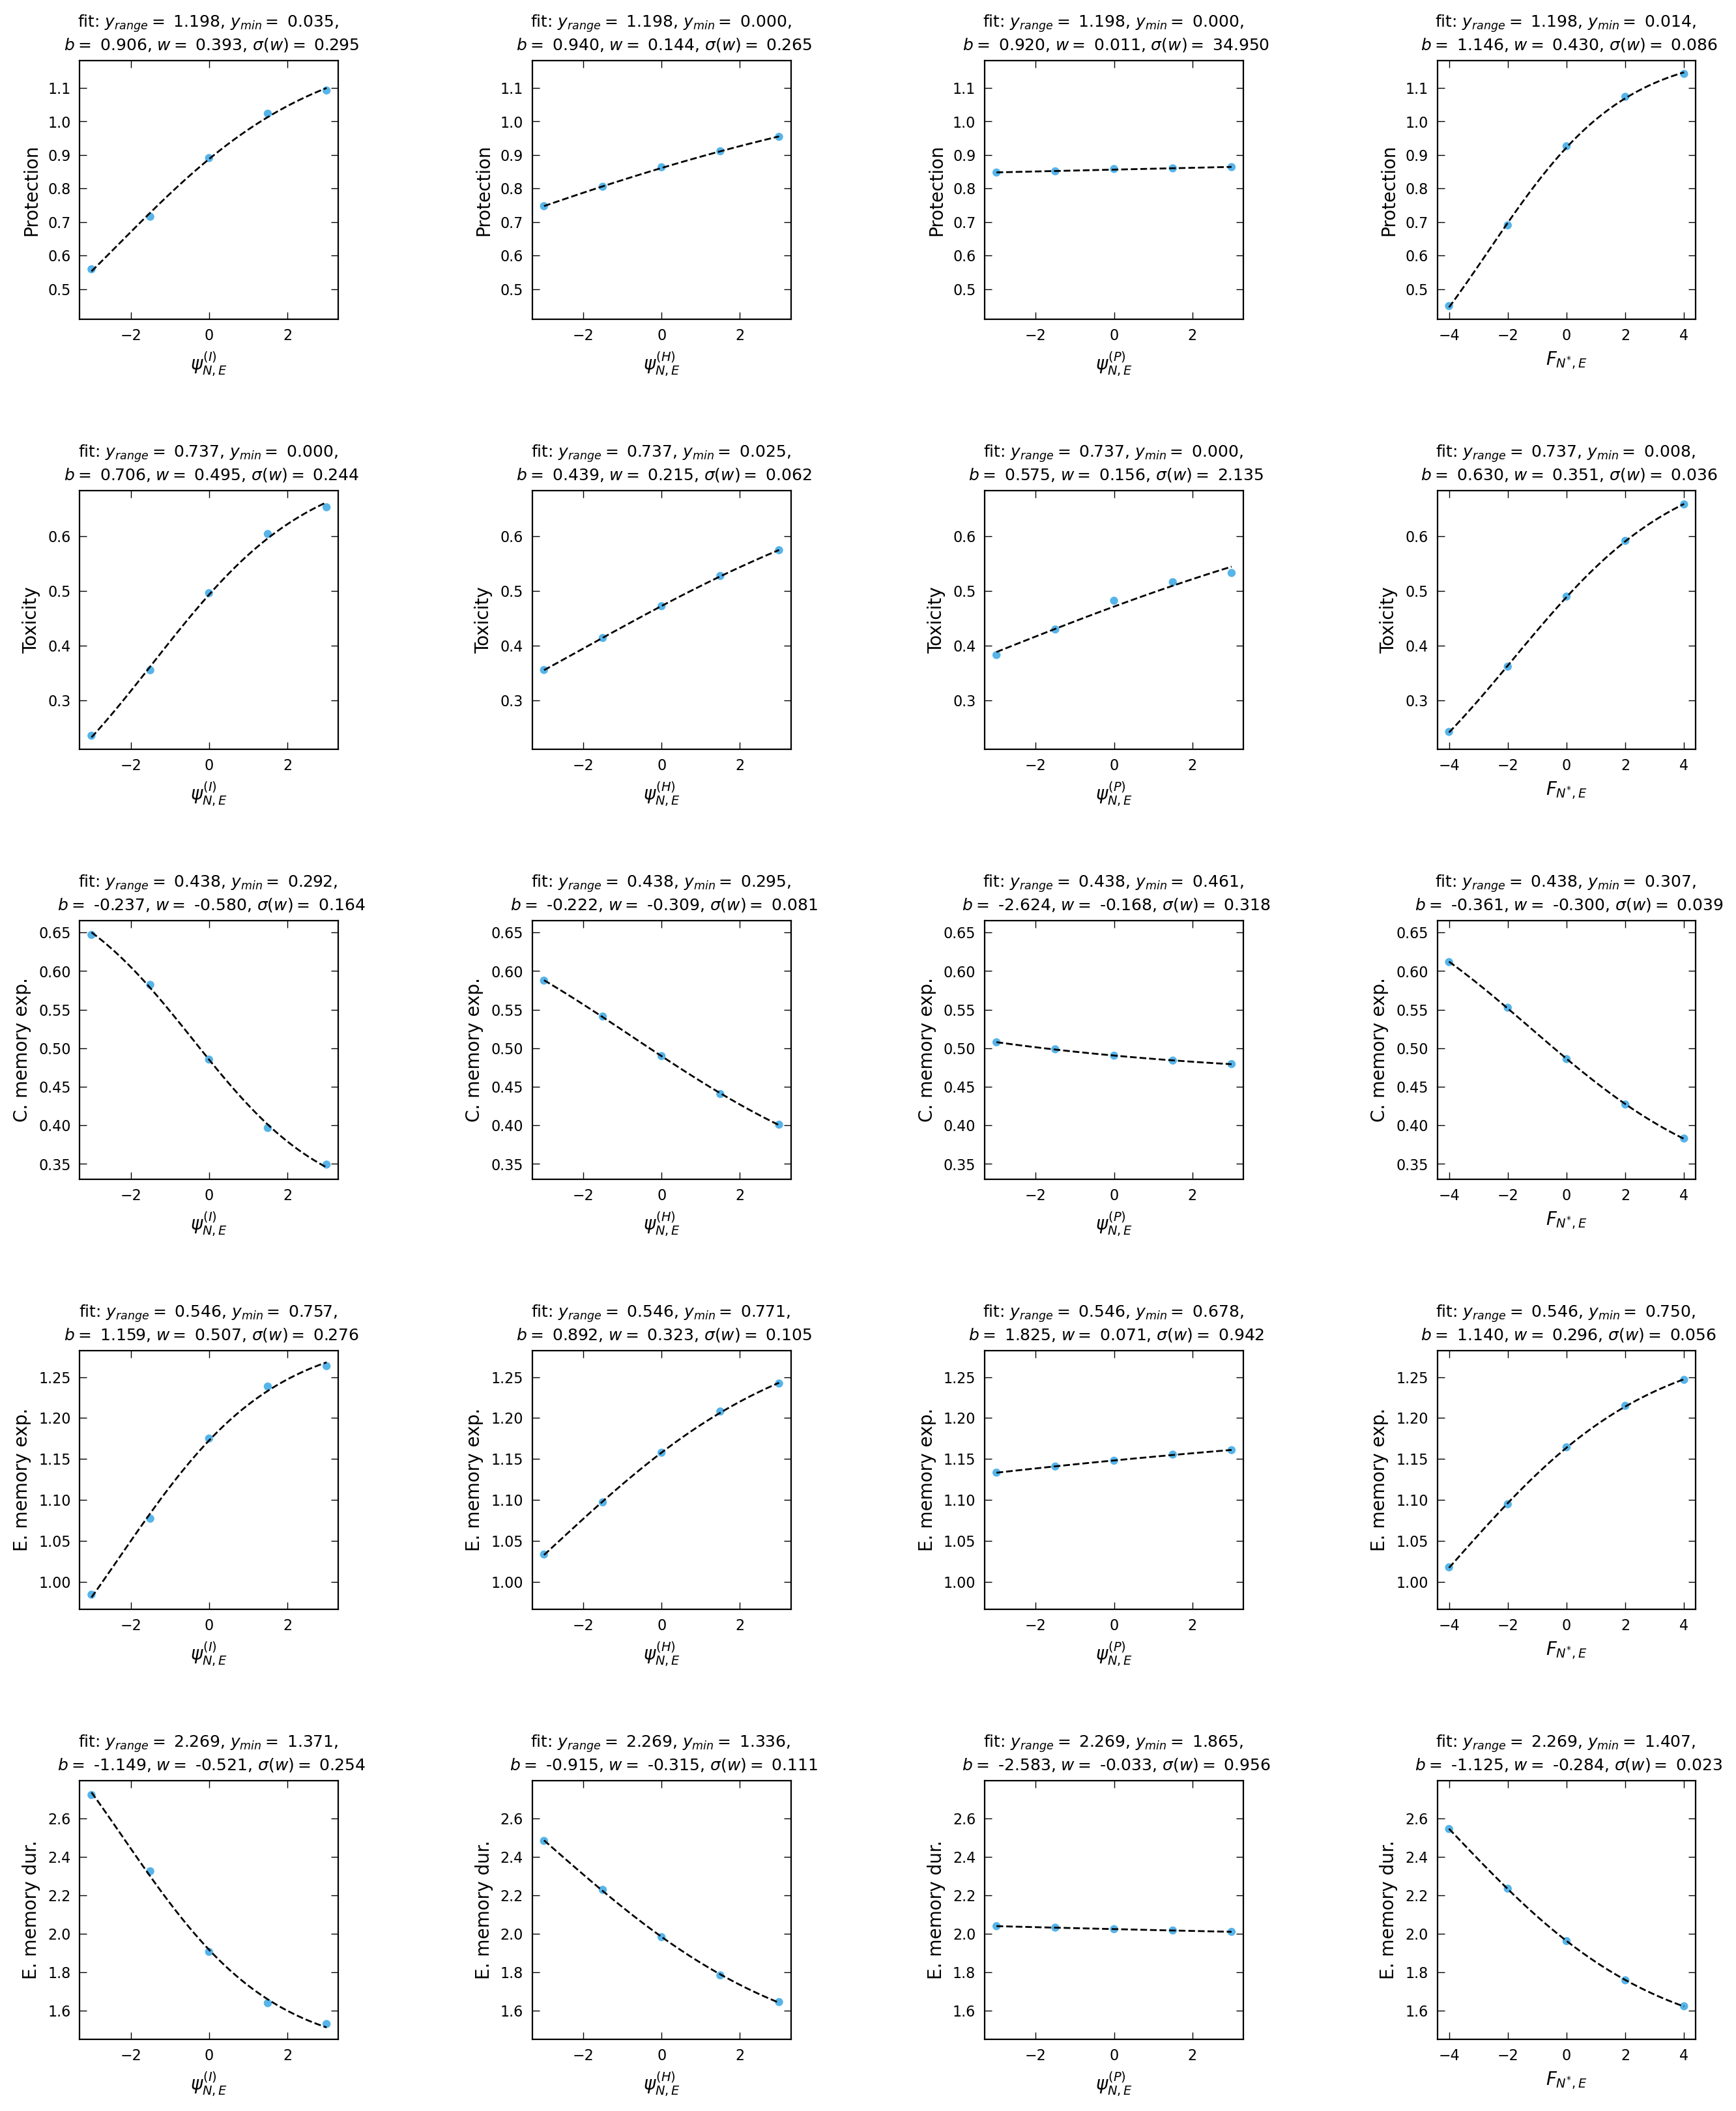

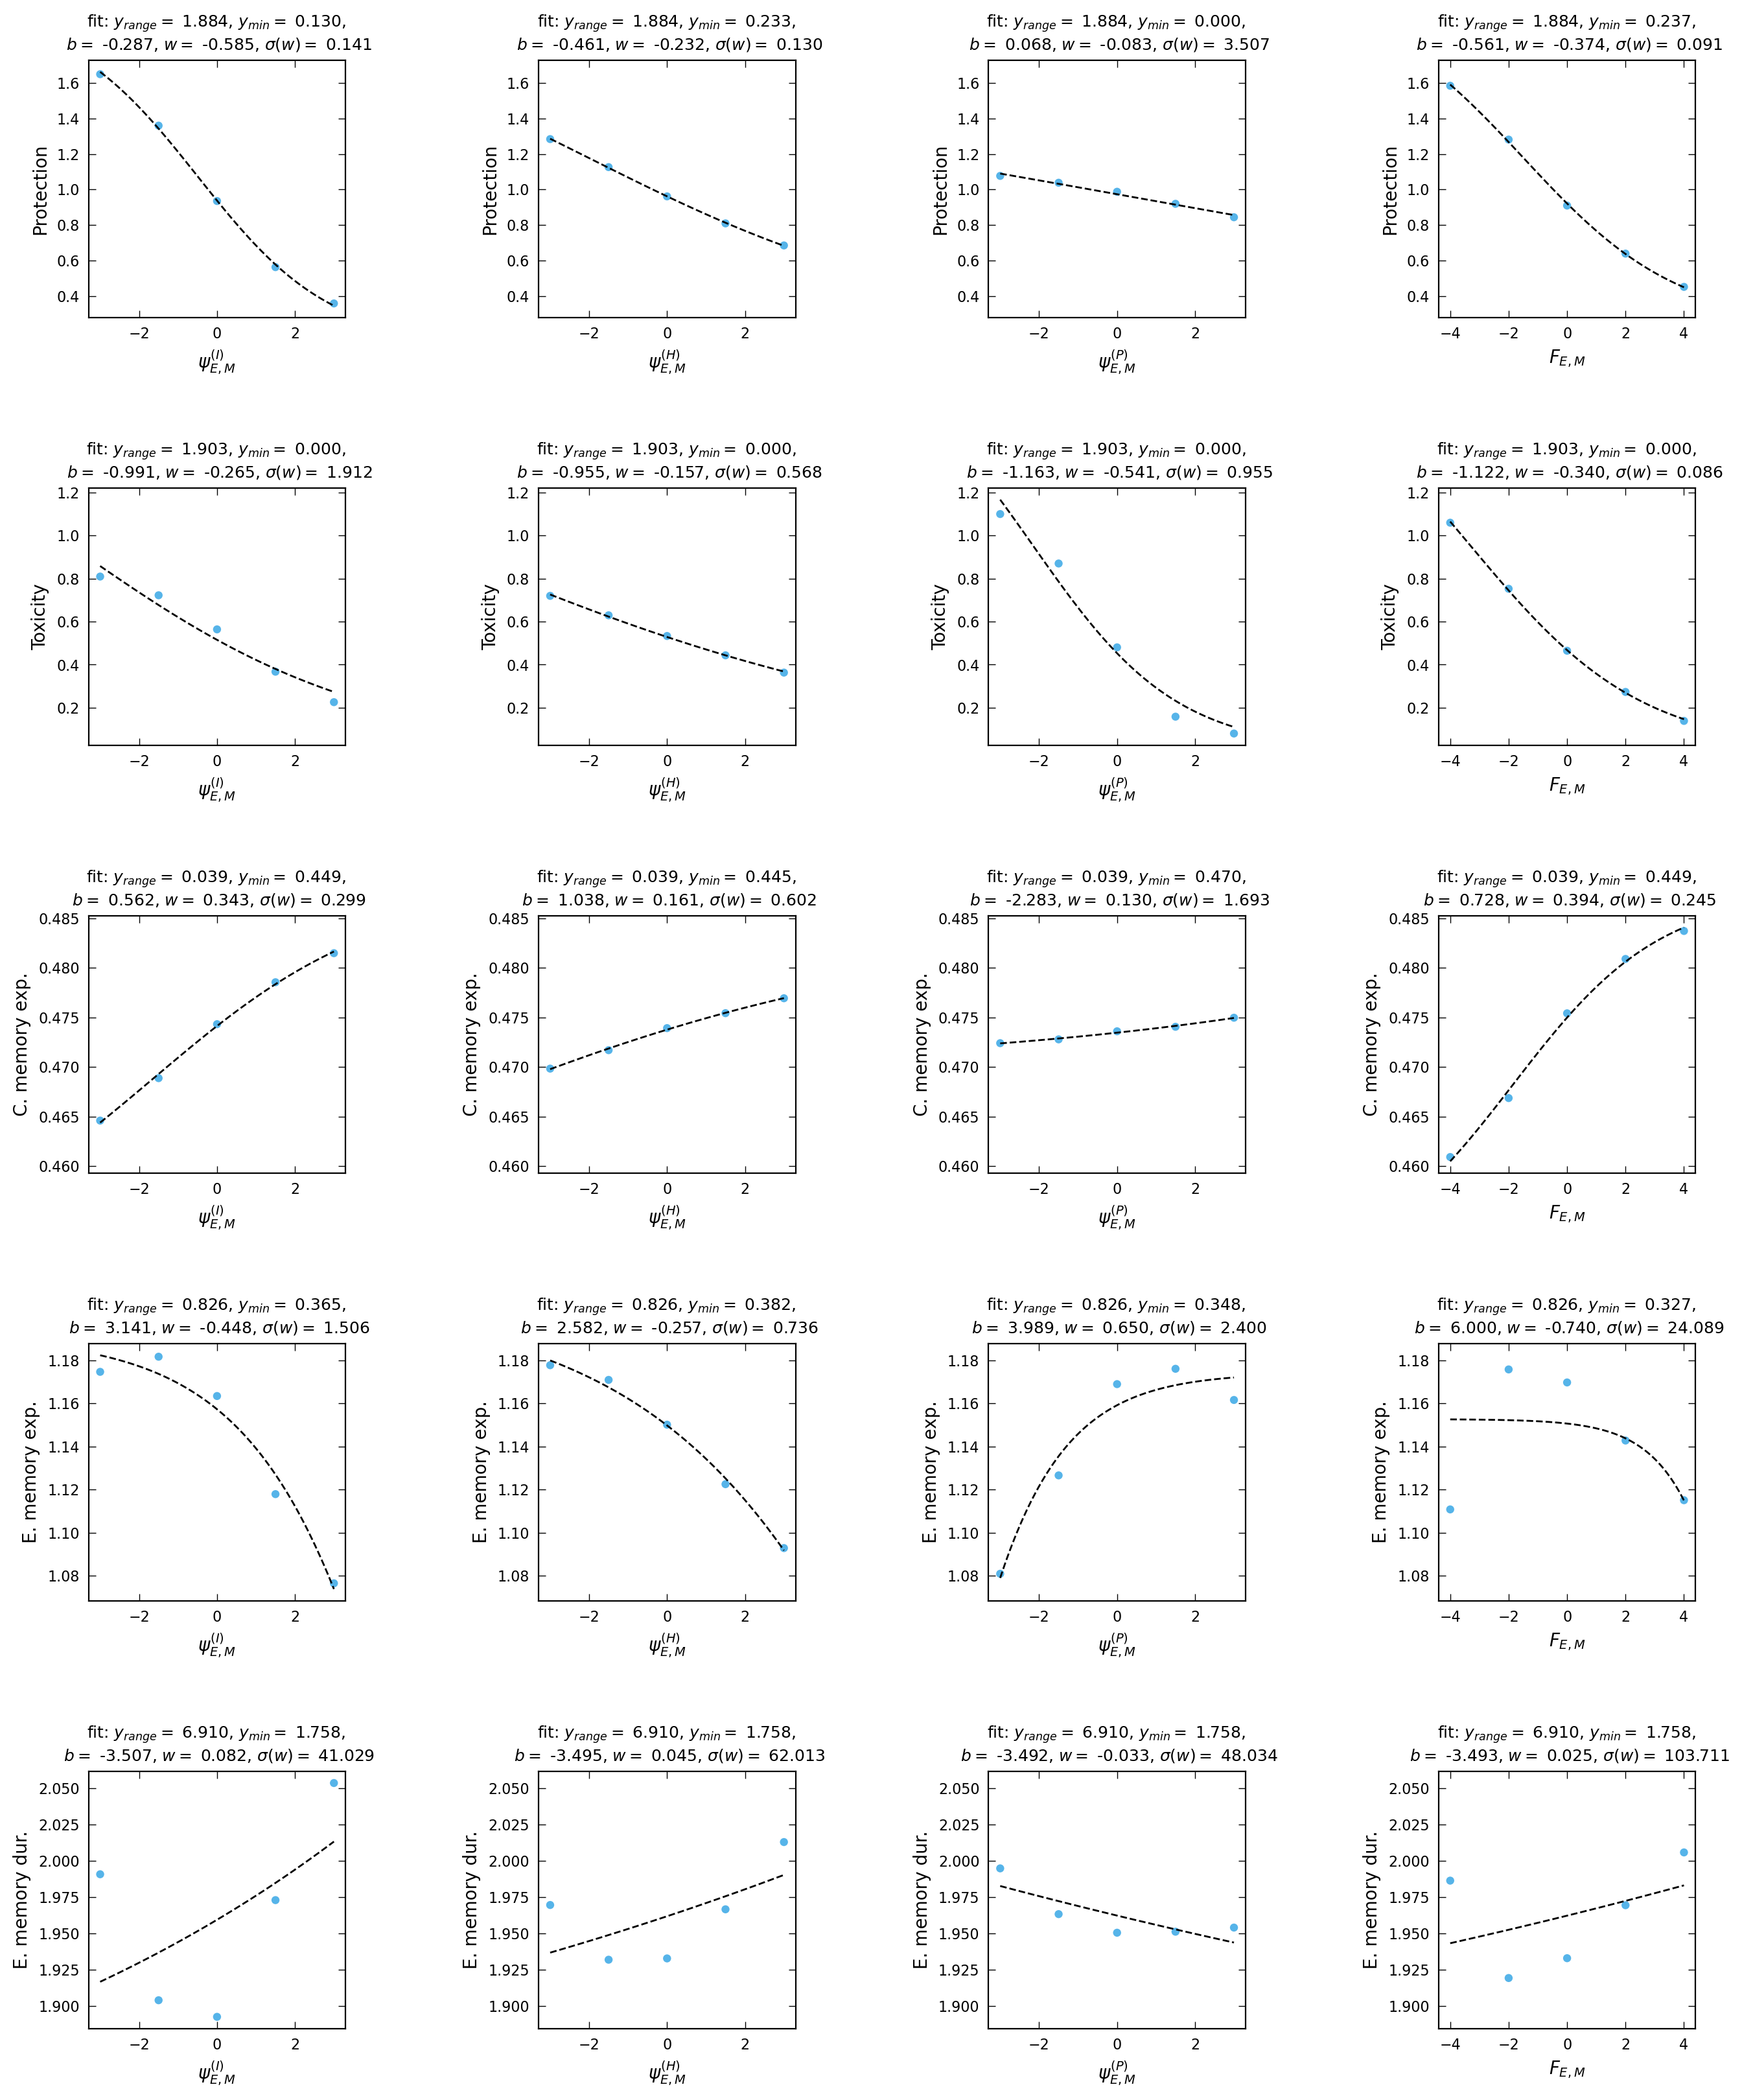

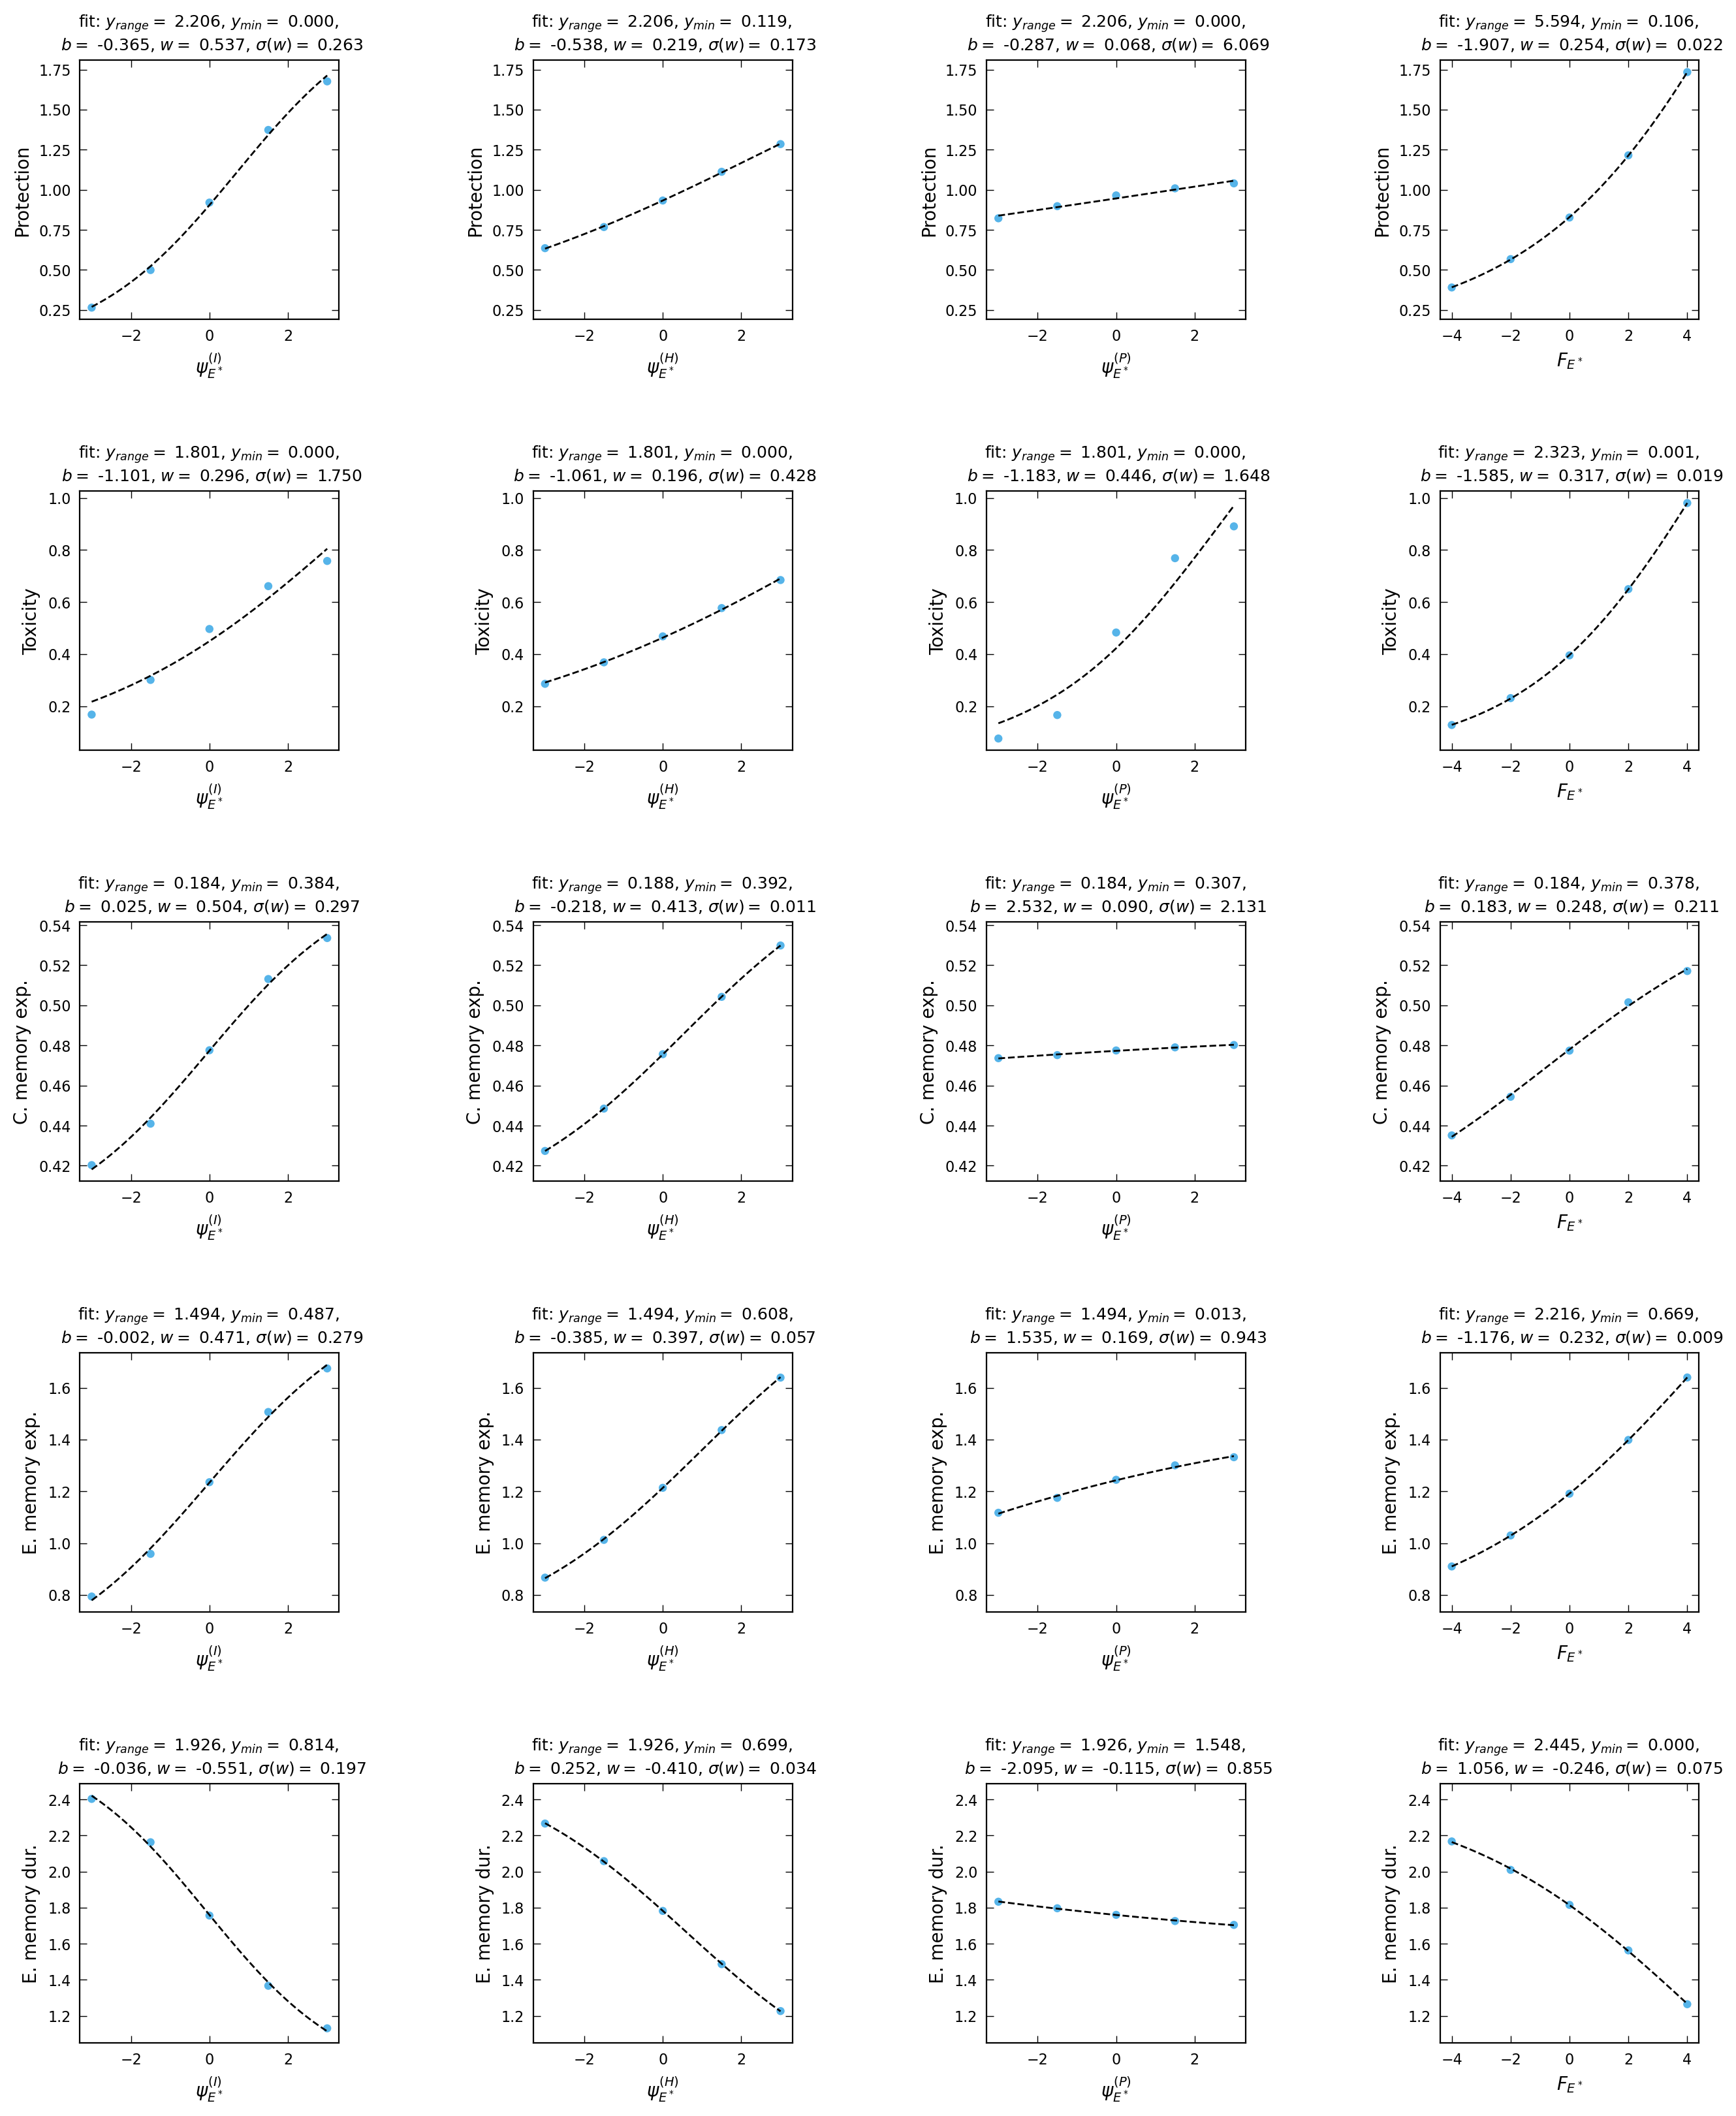

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 133
variables = reg

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min), 0.0 if y_min > 0.0 else y_min] + len(variables)*[-3.0*F0_max] + num_modules*[-3.0*F0_max], 
                                     [1.01*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[3.0*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [29]:
# View result
perf = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,0.376547,2.108657e-15,0.201758,0.003627,0.204494,4.127126,0.086356,0.147216,0.032711,0.940951,-0.121915,-0.026241,-0.219637,-1.643190,0.164555,0.049292,0.285381,2.418335,1.717472,1.339611,-3.230039,-8.665351,0.000791,0.000007,0.002304,0.002267,0.002305,0.107105,0.001084,0.001094,0.001079,0.001172,0.000900,0.000886,0.000929,0.003059,0.001023,0.000761,0.001512,0.004922,0.003197,0.002596,0.005587,0.014781,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.006217,0.376547,0.0,0.000000e+00,1.0,0.003785,0.032169,0.000000,0.094331,0.060789,0.022338,NaN
6,1.152982,7.203426e-05,0.211980,0.084025,0.425303,4.234265,0.090662,0.150257,0.080366,0.955176,-0.124993,-0.024889,-0.524710,-1.450844,0.162616,0.049285,0.721950,2.817145,1.884512,1.378113,-2.951956,-10.003510,0.001131,0.000024,0.002399,0.002346,0.002476,0.090643,0.001139,0.001150,0.001138,0.001257,0.000943,0.000921,0.001237,0.002200,0.000962,0.000922,0.001640,0.004804,0.003887,0.002775,0.003838,0.016681,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.019601,1.141566,0.0,0.000000e+00,1.0,0.012592,0.102384,0.000000,0.094330,0.060789,0.048981,NaN
11,3.803240,1.152145e-03,0.216225,0.170672,0.601895,3.948071,0.092233,0.153130,0.156290,0.951700,-0.122311,-0.028841,-0.875819,-1.423386,0.167274,0.058198,1.182677,3.136342,2.004449,1.362039,-2.995660,-11.432320,0.003654,0.000088,0.002821,0.002796,0.003053,0.037469,0.001358,0.001371,0.001372,0.001491,0.001067,0.001047,0.001978,0.002667,0.001259,0.001211,0.002615,0.005615,0.005133,0.003285,0.004676,0.020419,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.060823,3.765584,0.0,1.173613e-07,1.0,0.047209,0.323209,0.000000,0.094326,0.060789,0.093712,NaN
16,12.143052,3.619380e-03,0.231895,0.258815,0.773698,3.652312,0.090305,0.158754,0.252836,0.950603,-0.124427,-0.036650,-1.190569,-1.403807,0.173066,0.071576,1.562851,3.248635,2.085055,1.358896,-2.949810,-12.000000,0.012148,0.000310,0.003187,0.003208,0.003663,0.016469,0.001543,0.001560,0.001596,0.001676,0.001251,0.001227,0.002601,0.002837,0.001390,0.001340,0.003963,0.006859,0.006140,0.003687,0.004987,0.025789,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.190055,12.022824,0.0,5.953896e-07,1.0,0.166486,1.017709,0.000000,0.094315,0.060789,0.162677,NaN
21,37.380819,3.685602e-03,0.266343,0.350102,0.968457,3.682912,0.088539,0.160550,0.371898,0.936587,-0.106962,-0.036954,-1.582465,-1.447893,0.199639,0.082892,1.536209,2.692050,2.181042,1.361554,-2.969900,-9.893749,0.042527,0.001119,0.003827,0.003944,0.004817,0.015327,0.001816,0.001836,0.001957,0.001920,0.001567,0.001551,0.004298,0.003520,0.001469,0.001406,0.003954,0.006169,0.007646,0.004282,0.006235,0.023108,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.592569,37.010712,0.0,1.798404e-06,1.0,0.597282,3.157497,0.000000,0.094280,0.060789,0.261272,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,0.372214,3.760870e-16,0.251136,2.738582,0.163730,2.509888,0.099900,0.940794,0.099675,0.938208,-0.147409,-1.542054,-0.264373,-1.415037,0.189118,2.344424,0.279966,2.108277,0.504707,1.344408,-2.842842,-7.258072,0.000251,0.000008,0.002025,0.011342,

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

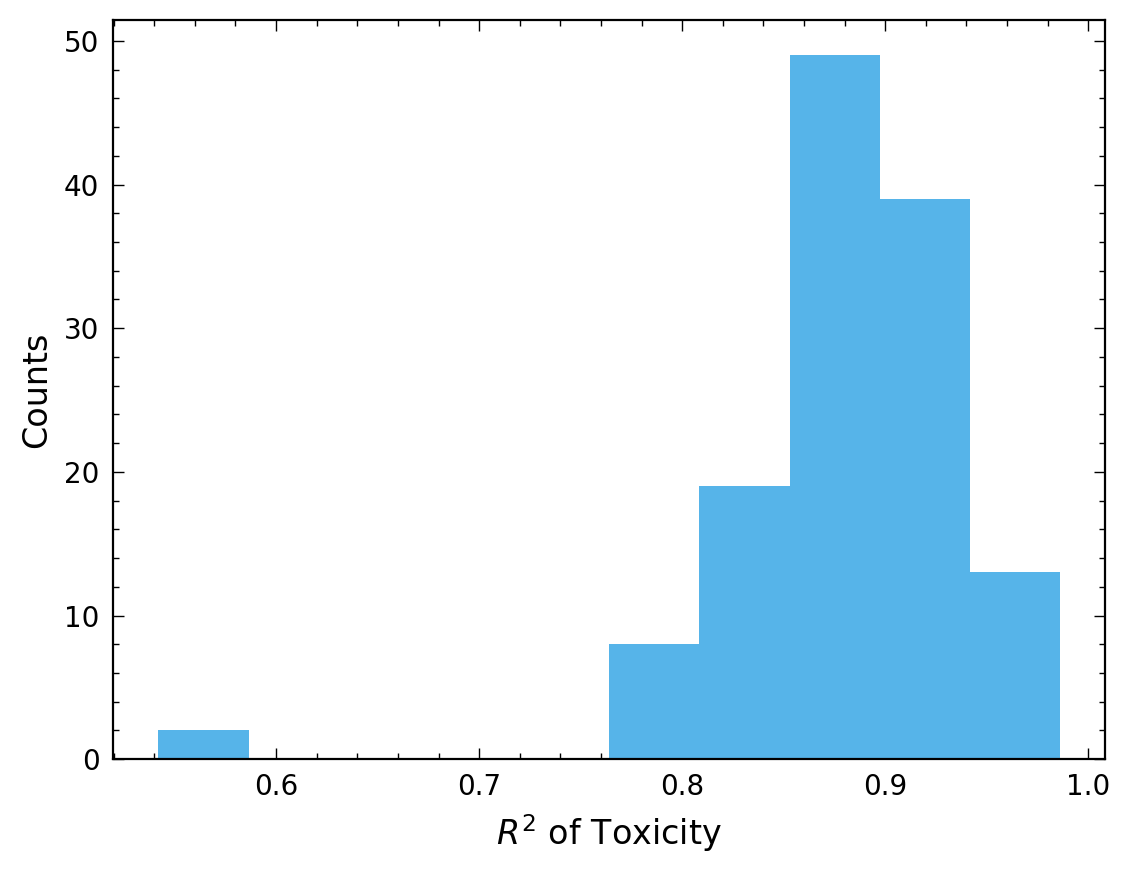

In [30]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

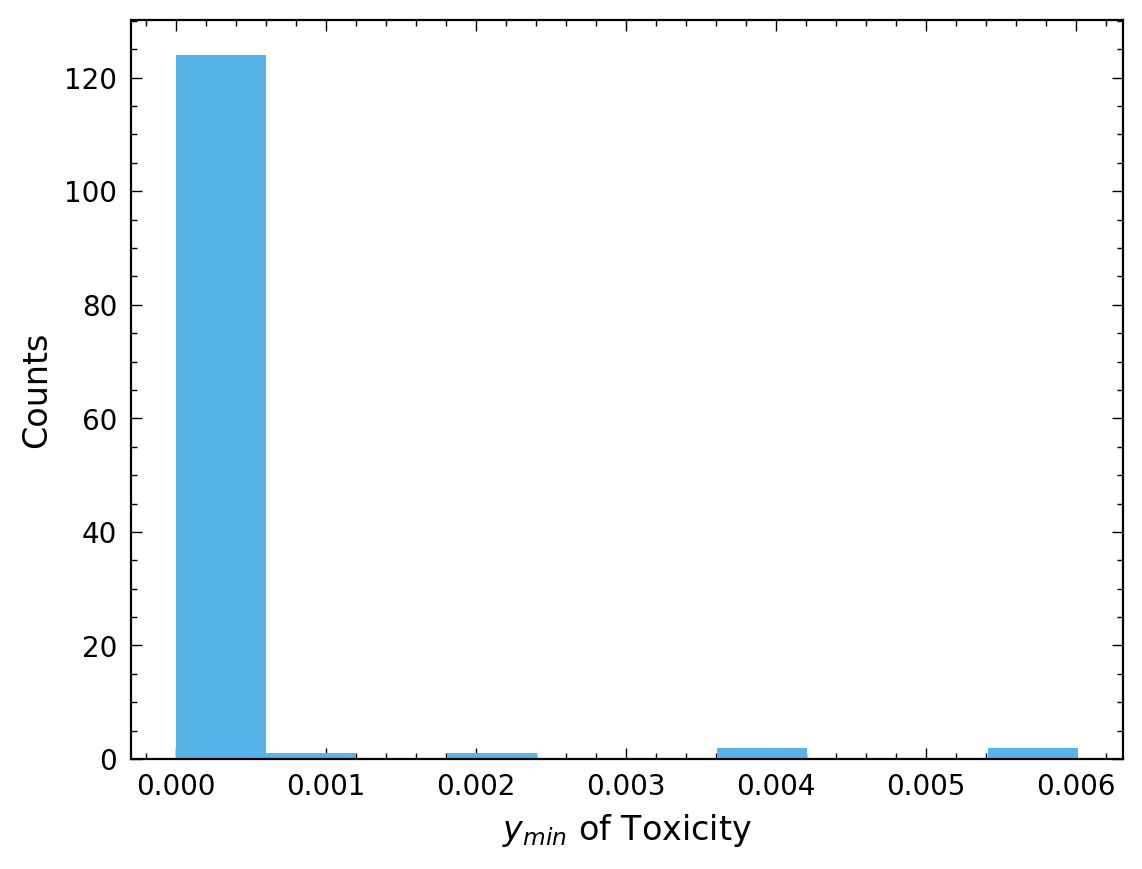

In [31]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

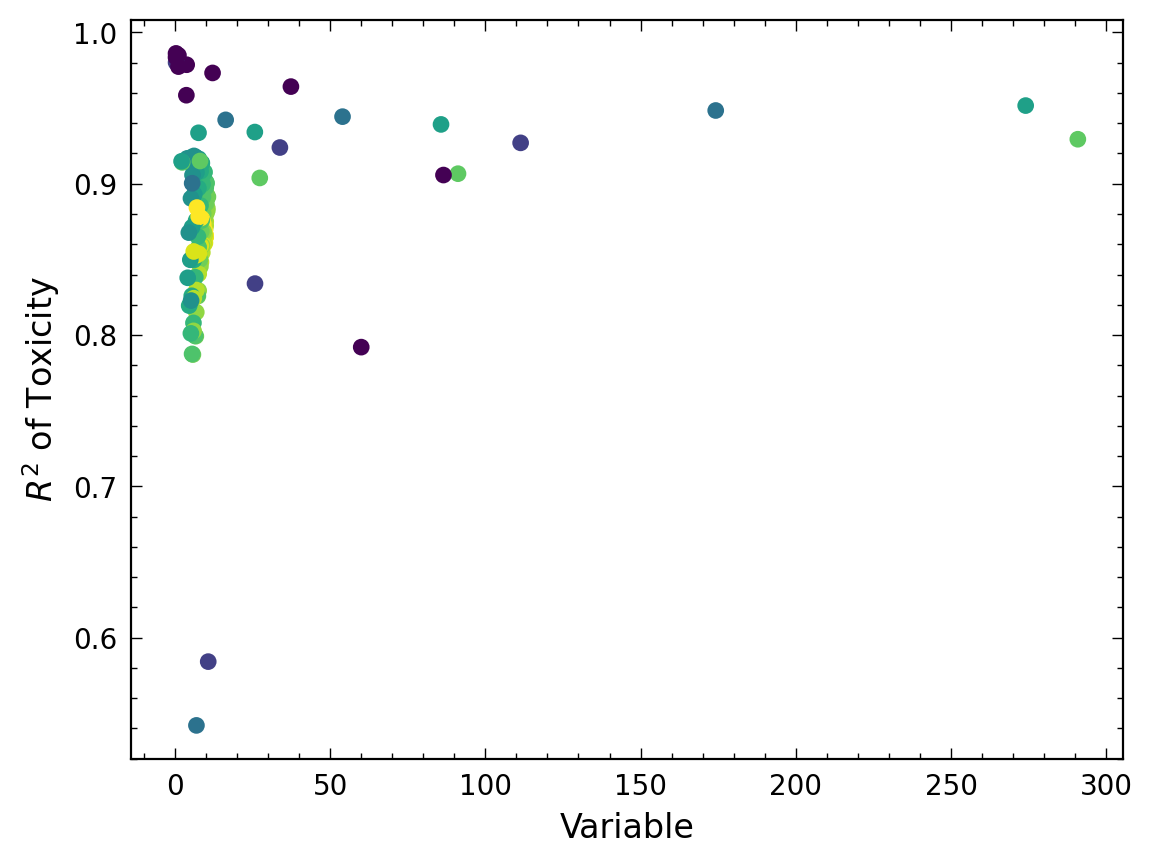

In [32]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].y_range, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

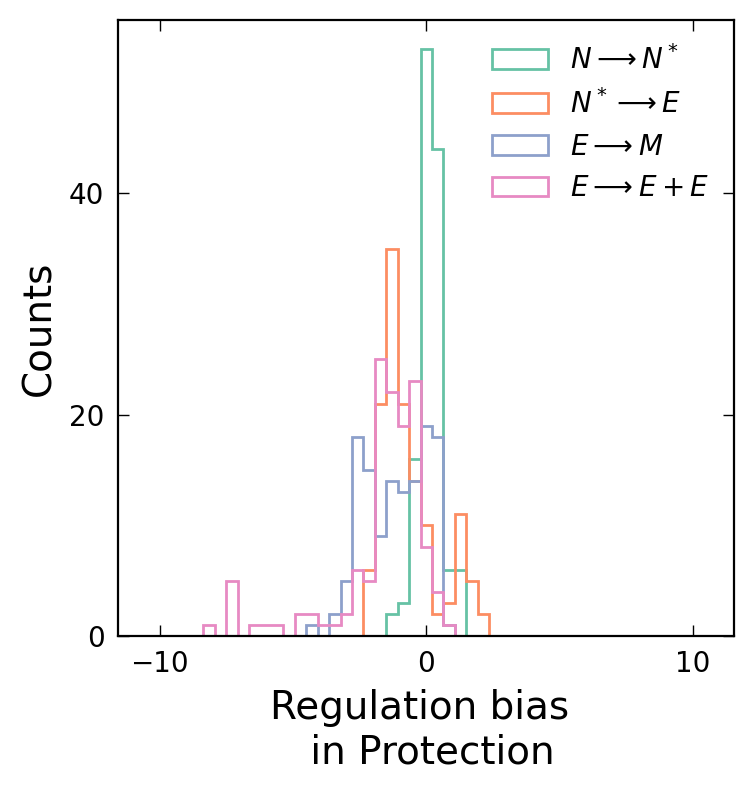

In [25]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

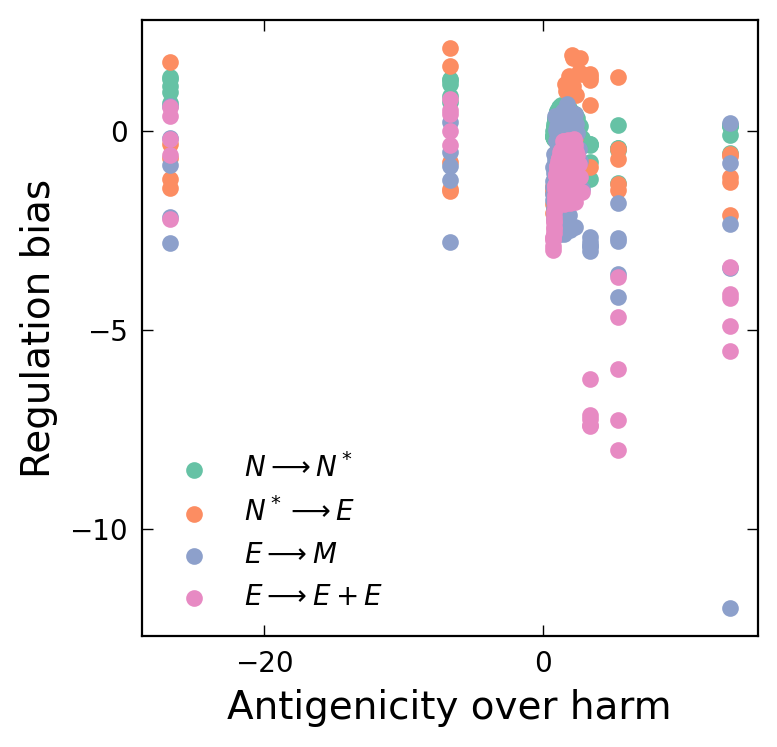

In [26]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

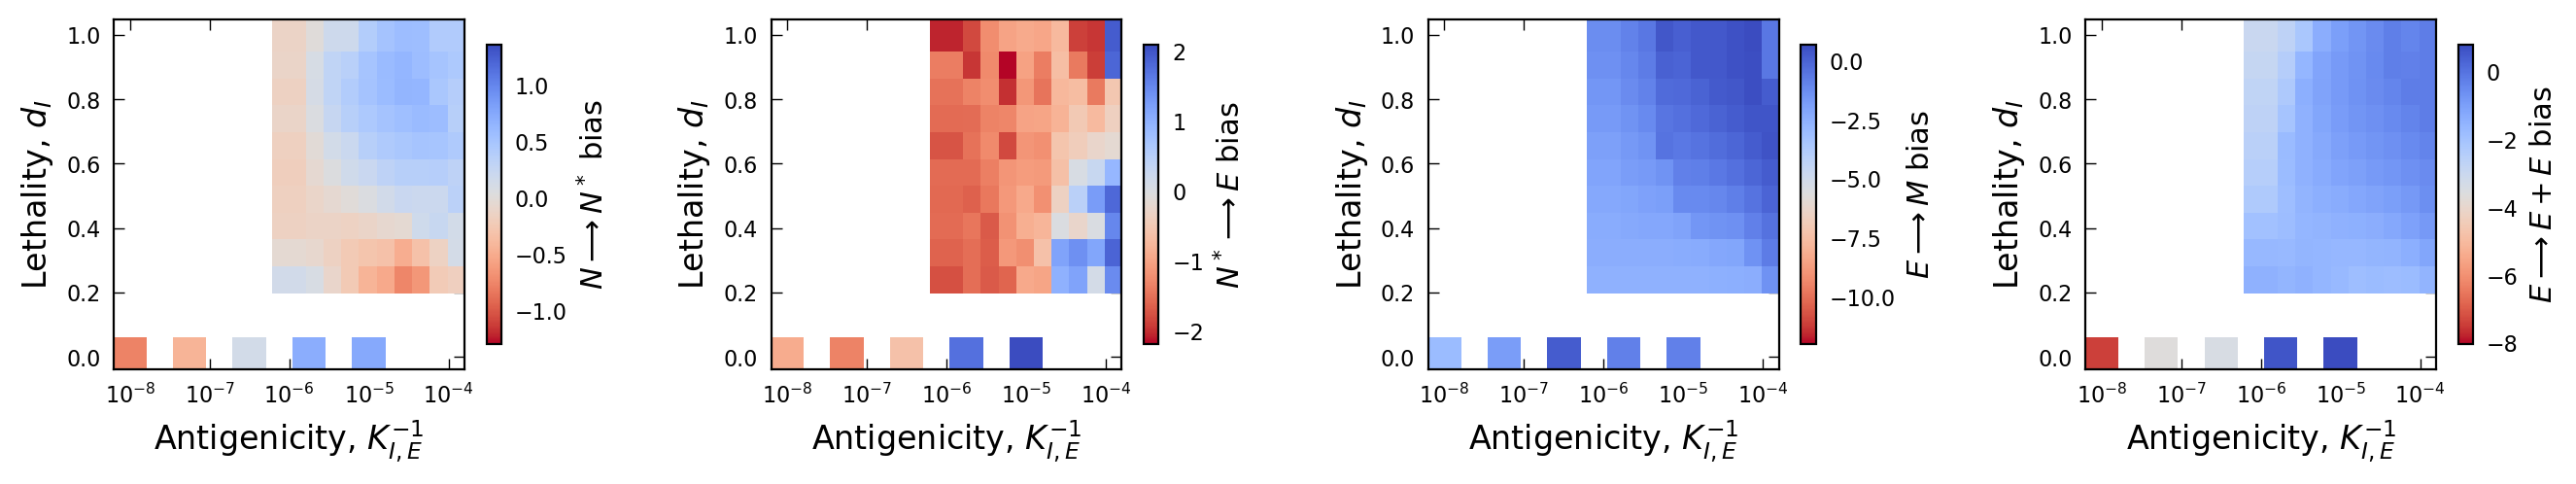

In [27]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

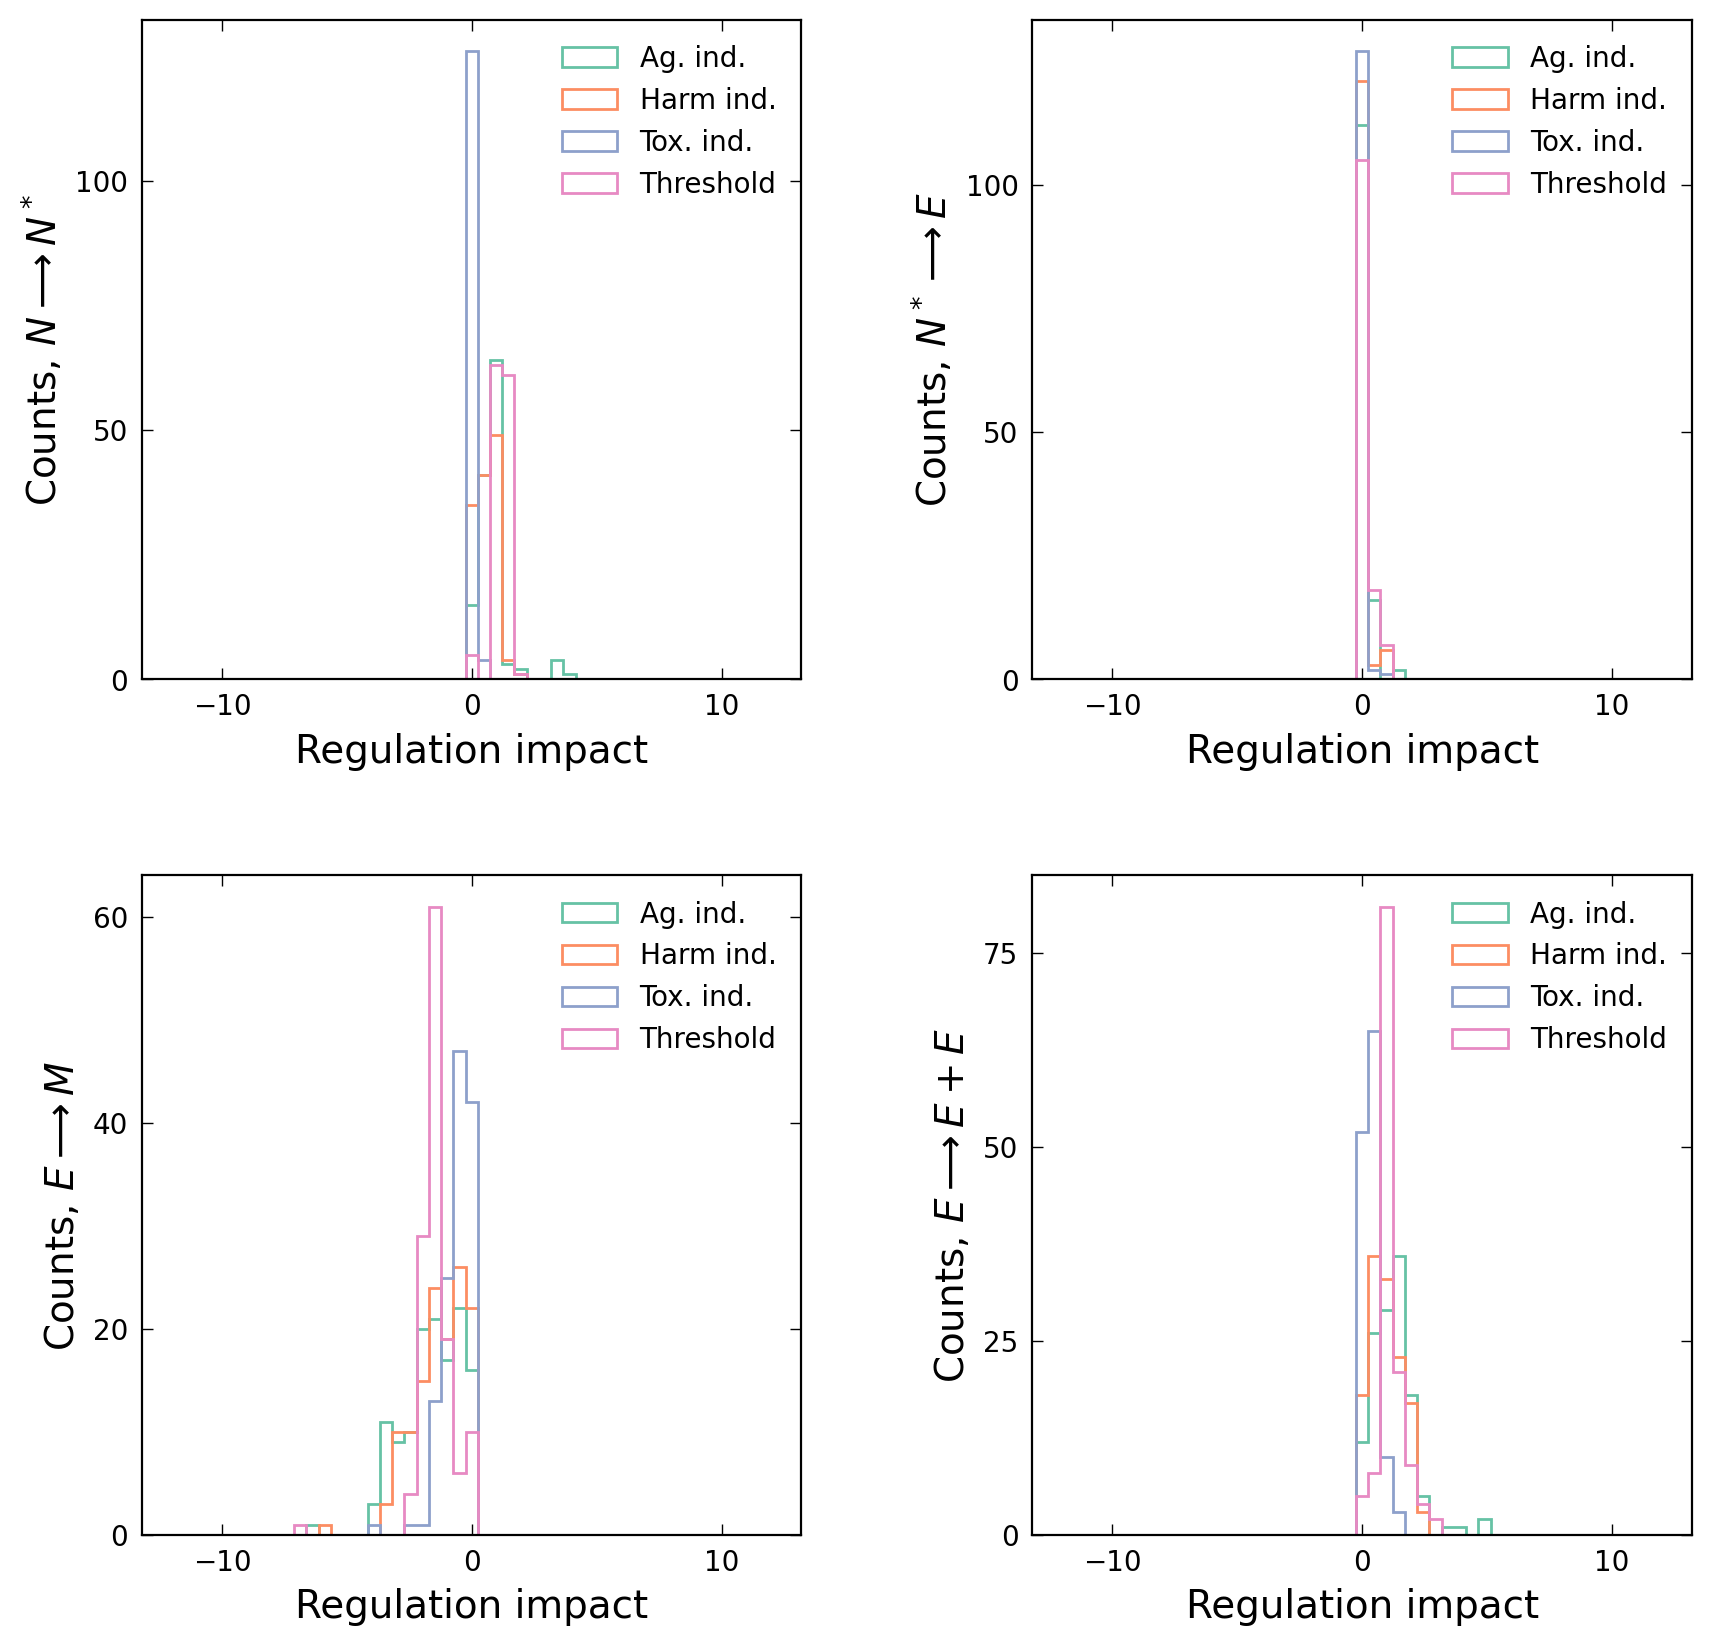

In [28]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*F0_max, 3.0*F0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
4,5.05,0.226178,0.258875,1.329373,0.000178,5.098153,-0.013264,-0.024264,0.000138,-0.256705,-0.373993,-0.059353,-0.156089,0.246773,-0.122273,-0.045121,-0.002955,-0.954348,-1.929418,2.375003,10.295090,2.394892,0.022992,0.002500,0.007682,0.011062,0.007368,0.133699,0.006046,0.006071,0.006036,0.009839,11.136454,7.135715,8.016661,10.421473,0.004148,0.004115,0.004110,0.004510,0.011197,0.054870,63.247008,0.013145,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,1.689213,5.0,0.0,0.000000,4.0,0.922157,2.075879,0.0,0.094331,0.060789,0.022338,NaN
9,5.05,0.253223,0.446391,2.032829,-0.008292,8.495548,-0.014374,-0.023274,0.000740,-0.243865,-0.746468,0.010195,-0.033371,0.318386,-0.133230,-0.038293,-0.010428,-1.037929,-2.096600,2.401763,8.192893,2.270123,0.022729,0.002403,0.010150,0.019153,0.008980,7.499916,0.006250,0.006275,0.006235,0.010424,0.744547,0.290111,0.291836,0.473976,0.004163,0.004118,0.004114,0.005002,0.012648,0.059871,3.205149,0.012750,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,1.666534,5.0,0.0,0.275072,4.0,0.899100,2.067965,0.0,0.094330,0.060789,0.048981,NaN
14,5.05,0.271794,0.551676,2.766517,0.010560,8.921928,-0.013511,-0.023934,-0.000719,-0.233045,-0.283626,-0.006067,-0.057353,0.296528,-0.134545,-0.031139,-0.028746,-1.080436,-1.921077,2.386842,6.189670,2.244732,0.026655,0.002412,0.012152,0.031020,0.010698,1.805481,0.006383,0.006418,0.006367,0.010870,0.174298,0.137068,0.139432,0.238516,0.004267,0.004218,0.004217,0.005423,0.011391,0.064238,1.248146,0.013136,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,1.678217,5.0,0.0,0.288502,4.0,0.906218,2.062826,0.0,0.094326,0.060789,0.093712,NaN
19,5.05,0.276500,0.417511,3.720618,-0.007325,9.702794,-0.013597,-0.022267,-0.001018,-0.224820,-0.139351,-0.001965,-0.113605,0.275214,-0.130274,-0.024186,-0.068644,-1.104535,-1.442055,2.346302,5.433624,2.313129,0.030617,0.002506,0.012765,0.119470,0.012947,1.178100,0.006473,0.006506,0.006454,0.011206,0.095913,0.086454,0.092942,0.151756,0.004462,0.004413,0.004425,0.005812,0.008489,0.067864,0.804639,0.013988,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,1.714380,5.0,0.0,0.321439,4.0,0.938505,2.063331,0.0,0.094315,0.060789,0.162677,NaN
24,5.05,0.278863,0.355304,4.733412,0.002459,10.173173,-0.012936,-0.021618,-0.002414,-0.211922,-0.089852,0.007229,-0.151921,0.252225,-0.133395,-0.022421,-0.144283,-1.163611,-0.849453,2.239675,5.041248,2.546080,0.036341,0.002696,0.012282,1.089564,0.011786,1.670629,0.006394,0.006434,0.006372,0.011415,0.070859,0.066774,0.077973,0.116784,0.004890,0.004833,0.004900,0.006652,0.006597,0.072247,0.648104,0.016066,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,1.775360,5.0,0.0,0.398907,4.0,1.002023,2.076142,0.0,0.094280,0.060789,0.261272,NaN


In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
529,5.05,0.230530,11.999850,4.246579,0.000585,4.005107,-0.583383,-0.168817,-0.001593,-0.228110,-0.209330,-0.027198,-0.039677,0.465149,-1.555754,-0.494464,-0.028064,-0.490991,11.644450,0.296394,5.145702,1.463031,0.026000,0.003928,0.234948,0.084539,0.018183,0.084057,0.005215,0.002992,0.002654,0.001795,0.043276,0.041267,0.041352,0.085171,0.012501,0.006658,0.005412,0.003658,0.226704,0.011710,0.377215,0.013484,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,1.730758,5.0,0.0,1.303120,4.0,0.992061,1.670559,2.651569,3.332503,1.131501,0.279167,-6.698971
534,5.05,0.238013,11.569244,3.384304,-0.005671,3.940796,-0.543415,-0.152831,-0.004232,-0.228137,-0.202466,-0.020962,-0.058919,0.490863,-1.590671,-0.515976,-0.062516,-0.506232,11.999902,0.534720,5.803755,1.127708,0.026402,0.004366,0.230137,0.071127,0.017431,0.078708,0.005458,0.003165,0.002865,0.002126,0.073633,0.070630,0.071161,0.154820,0.012298,0.006514,0.005208,0.003322,0.242248,0.013892,0.677858,0.011087,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,1.782906,5.0,0.0,1.290972,4.0,1.030304,1.740551,2.651569,3.279461,1.098376,0.426406,-6.698971
539,5.05,0.232512,11.358489,3.133931,-0.005915,3.903099,-0.532787,-0.148885,-0.011372,-0.229029,-0.180890,-0.016025,-0.106928,0.479202,-1.527220,-0.488841,-0.123116,-0.505654,11.999845,0.577173,5.660495,1.057716,0.026523,0.004401,0.222222,0.065750,0.017701,0.075422,0.005461,0.003178,0.002890,0.002193,0.066821,0.063915,0.065485,0.137228,0.011659,0.006210,0.005093,0.003248,0.238898,0.014300,0.603590,0.010672,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,1.781065,5.0,0.0,1.285815,4.0,1.027969,1.740315,2.651569,3.238619,1.084044,0.671635,-6.698971
544,5.05,0.228445,11.330739,3.059276,-0.004800,3.890572,-0.531016,-0.147948,-0.027022,-0.236712,-0.068072,0.008257,-0.207404,0.480233,-1.394888,-0.433598,-0.214134,-0.499146,11.999999,0.556974,5.471394,1.042475,0.026449,0.004429,0.221481,0.064138,0.017867,0.074891,0.005400,0.003161,0.002888,0.002215,0.053530,0.052936,0.055510,0.113165,0.010658,0.005782,0.005061,0.003232,0.238967,0.014078,0.497895,0.010735,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,1.765148,5.0,0.0,1.282285,4.0,1.020855,1.727108,2.651569,3.160658,1.017086,1.023732,-6.698971
549,5.05,0.212729,11.314384,3.027763,-0.008145,3.877565,-0.518669,-0.142822,-0.050379,-0.238330,0.010986,0.009394,-0.266264,0.459482,-1.198643,-0.350334,-0.339161,-0.497781,11.999987,0.554336,4.869392,1.071685,0.026975,0.004570,0.222912,0.063901,0.018043,0.074990,0.005372,0.003153,0.002917,0.002259,0.030759,0.030756,0.033253,0.062717,0.009335,0.005240,0.005201,0.003309,0.240924,0.014317,0.279995,0.011161,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,1.755829,5.0,0.0,1.279741,4.0,1.026482,1.719516,2.651569,3.085580,0.977892,1.401178,-6.698971
554,5.05,0.196076,6.777353,4.306937,-0.007715,4.399243,-0.298561,-0.186258,0.000674,-0.241694,-0.212739,-0.035676,-0.027985,0.373733,-0.891655,-0.586716,-0.024059,-0.565839,11.999532,0.456302,4.250416,1.261743,0.031390,0.003645,0.112580,0.071695,0.013906,0.076652,0.003760,0.003022,0.002424,0.002436,0.025410,0.023352,0.023318,0.041682,0.006884,0.005589,0.004230,0.003459,0.193213,0.016230,0.196314,0.011245,0.01,5.623413e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,1.744699,5.0,0.0,1.